In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
from AgentTorch.substep import SubstepTransition
from AgentTorch.helpers import get_by_path

In [32]:
class Combat(SubstepTransition):
    """
        Transition function for the combat substep
        Update the state of the grid consisting of both tumor and immune cells after
        the combat with change in the parameters of the cells

        Args:
            config (dict): the initial state
            input_variables (dict): dictionary of input variables
            output_variables (dict): dictionary of output variables
            arguments (dict): dictionary of arguments

        Returns:
            state (dict): the updated state

        Parameters:

            IMkmax (tensor): the maximum interaction (killing) capacity of an immune cell, 
                the length to which the immune cell can survive
            kill_cell_index (tensor): the index of the tumor cell that is killed
            CD8_engagement_status (tensor): the engagement status of the immune cell
            TUintmax (tensor): the maximum interaction capacity of a tumor cell with immune cells, 
                length to which the tumor cell can survive
            Tum_engagement_status (tensor): the engagement status of the tumor cell
            engagementDuration (tensor): the engagement duration between the tumor and immune cells

        Steps:
            1. Feed the initial state to the transition function
            2. Get the input variables from the state and the target cells using action substep
            3. Rule is with each iteration of the engagementDuration parameter, the immune
            killing capacity (IMkmax parameter) gets reduced by one, while engagementDuration
            continuously drops until it becomes negative. EngagementDuration stays 1 during combat
            4. Each attack decreases the immune killing capacity (IMkmax) and tumor killing capacity
            (TUintmax) by 1, and the engagementDuration by 1.
            5. If the engagementDuration becomes negative, the combat ends and the cells survive.
            6. If the IMkmax or TUintmax becomes negative, that cell dies.
            7. Update the state of the grid with the new parameters of the cells
            
    """
    def __init__(self, config, input_variables, output_variables, arguments):
        super().__init__(config, input_variables, output_variables, arguments)
    
    def forward(self, state):
        IMkmax = get_by_path(state, re.split("/", self.input_variables["IMkmax"]))
        kill_cell_index = get_by_path(state, re.split("/", self.input_variables["kill_cell_index"]))
        CD8_engagement_status = get_by_path(state, re.split("/", self.input_variables["CD8_engagement_status"]))
        TUintmax = get_by_path(state, re.split("/", self.input_variables["TUintmax"]))
        Tum_engagement_status = get_by_path(state, re.split("/", self.input_variables["Tum_engagement_status"]))
        engagementDuration = get_by_path(state, re.split("/", self.input_variables["engagementDuration"]))
        
        engagement_steps = engagementDuration.max()
        immune_cell_index = torch.tensor(self.config['agents']['tumorcells']['id'])
        tumor_cell_index = kill_cell_index

        # rules for killing TU cells, remove from the grid and update the state
        IM_health = torch.zeros_like(immune_cell_index)
        TU_health = torch.zeros_like(kill_cell_index)
        
        IM_health = IMkmax[immune_cell_index]
        TU_health[:] = TUintmax[kill_cell_index]
        
        for t in range(engagement_steps):
            done = (IM_health <= 0) | (TU_health <= 0)
            if done.all():
                break
                
            IM_health = IM_health - 1
            TU_health = TU_health - 1
            
        IM_survived = torch.tensor((IM_health > 0), dtype=torch.float32)
        TU_survived = torch.tensor((TU_health > 0), dtype=torch.float32)
        
        state['cell_grid'][immune_cell_index] *= IM_survived 
        state['cell_grid'][kill_cell_index] *= TU_survived
        engagementDuration[immune_cell_index] = torch.zeros_like(engagementDuration[immune_cell_index])
        engagementDuration[kill_cell_index] = torch.zeros_like(engagementDuration[kill_cell_index])
        IMkmax[immune_cell_index] = IM_health
        TUintmax[kill_cell_index] = TU_health
        CD8_engagement_status[immune_cell_index] = torch.zeros_like(CD8_engagement_status[immune_cell_index])
        Tum_engagement_status[kill_cell_index] = torch.zeros_like(Tum_engagement_status[kill_cell_index])

        return state

In [33]:
config = {
    'agents': {
        'tumorcells': {
            'id': 0,
            'kill_cell_index': torch.tensor([0]),
            'Tum_engagement_status': torch.tensor([0]),
            'TUintmax': torch.tensor([2]),  
            'CD8_engagement_status': torch.tensor([0]),
            'IMkmax': torch.tensor([5]),
            'engagementDuration': torch.tensor([48]),
        }
    },
    'cell_grid': torch.tensor(torch.randn(10, 10)),   
} 

input_variables = {
    'kill_cell_index': 'agents/tumorcells/kill_cell_index', 
    'IMkmax': 'agents/tumorcells/IMkmax',
    'CD8_engagement_status': 'agents/tumorcells/CD8_engagement_status',
    'TUintmax': 'agents/tumorcells/TUintmax',
    'Tum_engagement_status': 'agents/tumorcells/Tum_engagement_status',
    'engagementDuration': 'agents/tumorcells/engagementDuration',
}

output_variables = {}
arguments = {
    'learnable': {}, 
    'fixed': {}       
}
combat_cell = Combat(config, input_variables, output_variables, arguments)

/var/folders/nc/f38nz9pd527gj9dz_9vv58rh0000gn/T/ipykernel_30529/2874175562.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'cell_grid': torch.tensor(torch.randn(10, 10)),


In [34]:
output_state = combat_cell(config)

/var/folders/nc/f38nz9pd527gj9dz_9vv58rh0000gn/T/ipykernel_30529/480849477.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  IM_survived = torch.tensor((IM_health > 0), dtype=torch.float32)
/var/folders/nc/f38nz9pd527gj9dz_9vv58rh0000gn/T/ipykernel_30529/480849477.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  TU_survived = torch.tensor((TU_health > 0), dtype=torch.float32)


In [35]:
print("\nState after Migration:")
print(output_state)


State after Migration:
{'agents': {'tumorcells': {'id': 0, 'kill_cell_index': tensor([0]), 'Tum_engagement_status': tensor([0]), 'TUintmax': tensor([0]), 'CD8_engagement_status': tensor([0]), 'IMkmax': tensor([3]), 'engagementDuration': tensor([0])}}, 'cell_grid': tensor([[ 0.0000,  0.0000, -0.0000,  0.0000,  0.0000, -0.0000,  0.0000,  0.0000,
          0.0000, -0.0000],
        [ 0.1347, -1.4638,  0.9957, -0.0364,  0.1819, -0.7534,  0.6323, -0.7356,
         -0.2988,  2.1275],
        [ 1.2266, -0.5628, -1.0011,  2.1618,  0.3349, -1.6926,  0.5166,  0.0324,
          1.1334, -0.3516],
        [-0.5263, -1.9548,  1.1936,  0.4486,  1.6119, -0.5581, -0.6830,  1.6574,
         -0.3856, -0.8219],
        [ 1.0800,  0.9024, -0.9278,  1.2072,  1.1785, -1.6018, -0.0475,  0.3586,
          0.3665, -0.3569],
        [-1.6608, -0.6656,  0.1611, -0.1104, -0.9048,  1.9752,  0.7198,  1.5722,
         -0.4554, -0.3574],
        [ 1.8041, -1.0460,  0.8266, -0.2078, -0.9034, -0.0918,  1.8083,  0.7257,

In [36]:
output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])

In [37]:
print(output_state_sum)
loss = output_state_sum

tensor(3)


In [38]:
loss.requires_grad

False

In [24]:
loss.backward()

In [25]:
input_state_sum = sum([torch.sum(tensor) for tensor in config['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])

In [26]:
input_state_sum.requires_grad

True

In [27]:
import torch
import torch.optim as optim

In [34]:
TUintmax = config['agents']['tumorcells']['TUintmax']
optimizer = optim.SGD([TUintmax], lr=0.01)

In [35]:
grad_values = []

for epoch in range(10):
    # Forward pass
    output_state = combat_cell(config)
    output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])
    loss = torch.sum(output_state_sum)
    # Backward pass
    loss.backward()
    # Print or plot the gradient values
    print('Gradient of migrateTUcell:', TUintmax.grad)
    # Store migrateTUcell.grad values in the list
    grad_values.append(TUintmax.grad.item())
    # Optimize
    optimizer.step()
    # Print or plot the updated migrateTUcell values
    print('Updated migrateTUcell:', TUintmax)
    # Print or plot the loss
    print('Loss:', loss.item())
    # Clear gradients for the next iteration
    optimizer.zero_grad()

Gradient of migrateTUcell: tensor([4.])
Updated migrateTUcell: tensor([1.9600], requires_grad=True)
Loss: 49.061092376708984
Gradient of migrateTUcell: tensor([1.])
Updated migrateTUcell: tensor([1.9500], requires_grad=True)
Loss: 49.02109146118164
Gradient of migrateTUcell: tensor([1.])
Updated migrateTUcell: tensor([1.9400], requires_grad=True)
Loss: 49.01109313964844
Gradient of migrateTUcell: tensor([1.])
Updated migrateTUcell: tensor([1.9300], requires_grad=True)
Loss: 49.00109100341797
Gradient of migrateTUcell: tensor([1.])
Updated migrateTUcell: tensor([1.9200], requires_grad=True)
Loss: 48.991092681884766
Gradient of migrateTUcell: tensor([1.])
Updated migrateTUcell: tensor([1.9100], requires_grad=True)
Loss: 48.98109436035156
Gradient of migrateTUcell: tensor([1.])
Updated migrateTUcell: tensor([1.9000], requires_grad=True)
Loss: 48.971092224121094
Gradient of migrateTUcell: tensor([1.])
Updated migrateTUcell: tensor([1.8900], requires_grad=True)
Loss: 48.96109390258789
Gradi

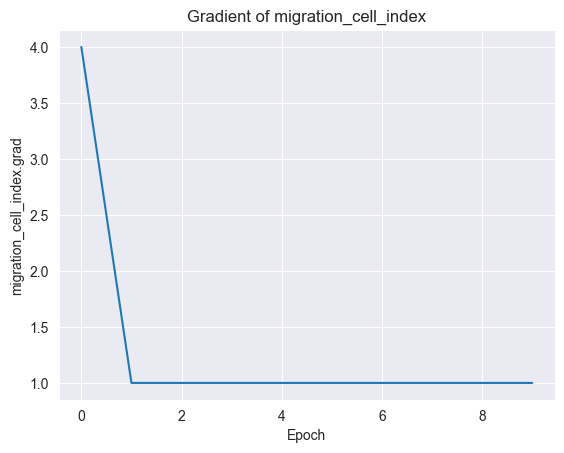

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.plot(grad_values)
plt.xlabel('Epoch')
plt.ylabel('migration_cell_index.grad')
plt.title('Gradient of migration_cell_index')
plt.show()